In [7]:
!pip install matplotlib numpy pandas

In [8]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import defaultdict
import os

# Display plots inline
%matplotlib inline

# Make plots bigger for better visibility
plt.rcParams['figure.figsize'] = (14, 6)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


In [12]:
# Define your file path - UPDATE THIS PATH
file_path = r"C:/Users/yonat/OneDrive/Desktop/MyPythonProject/notebooks/2025.bmerawdata"

# Check if file exists
if os.path.exists(file_path):
    print(f"✓ File found!")
    print(f"  Location: {file_path}")
else:
    print(f"✗ File not found. Check path:")
    print(f"  {file_path}")
    
    # Show available files
    print(f"\nAvailable files in bme688 folder:")
    bme_folder = r"C:/Users/yonat/OneDrive/Desktop/MyPythonProject/notebooks/bme688 (1)"
    if os.path.exists(bme_folder):
        for file in os.listdir(bme_folder):
            print(f"  - {file}")

✓ File found!
  Location: C:/Users/yonat/OneDrive/Desktop/MyPythonProject/notebooks/2025.bmerawdata


In [13]:
# Load the .bmerawdata file to verify my file path works before loading
try:
    with open(file_path, 'r') as f:
        data = json.load(f)
    print("✓ Successfully loaded .bmerawdata file!")
    print(f"  File size: {os.path.getsize(file_path) / 1024 / 1024:.2f} MB")
except Exception as e:
    print(f"✗ Error loading file: {e}")

✓ Successfully loaded .bmerawdata file!
  File size: 0.99 MB


In [14]:
# Extract main sections or configuration section
config_body = data.get("configBody", {})
raw_data_body = data.get("rawDataBody", {})

print("=" * 80)
print("1. HEATER PROFILES")
print("=" * 80)

heater_profiles = config_body.get("heaterProfiles", [])
profile_info = {}

for profile in heater_profiles:
    profile_id = profile.get("id")
    time_base = profile.get("timeBase")
    temp_vectors = profile.get("temperatureTimeVectors", [])
    duration = sum([tv[1] for tv in temp_vectors]) * time_base / 1000
    
    profile_info[profile_id] = {
        "time_base_ms": time_base,
        "num_steps": len(temp_vectors),
        "duration_sec": duration,
        "temp_sequence": [tv[0] for tv in temp_vectors]
    }
    
    print(f"\nProfile: {profile_id}")
    print(f"  - Time Base: {time_base} ms")
    print(f"  - Steps: {len(temp_vectors)}")
    print(f"  - Duration: {duration:.2f} seconds")
    print(f"  - Temperatures: {[tv[0] for tv in temp_vectors]}")

1. HEATER PROFILES

Profile: heater_354
  - Time Base: 140 ms
  - Steps: 10
  - Duration: 10.78 seconds
  - Temperatures: [320, 100, 100, 100, 200, 200, 200, 320, 320, 320]


In [19]:
# Sensor configuration
print("\n" + "=" * 80)
print("2. SENSOR CONFIGURATIONS(Sensor uses which configuration)")
print("=" * 80)

sensor_configs = config_body.get("sensorConfigurations", [])
sensor_profile_map = {}

for config in sensor_configs:
    sensor_idx = config.get("sensorIndex")
    heater_profile = config.get("heaterProfile")
    sensor_profile_map[sensor_idx] = heater_profile
    print(f"Sensor {sensor_idx} → {heater_profile}")

print(f"\nTotal sensors found: {len(sensor_profile_map)}")


2. SENSOR CONFIGURATIONS(Sensor uses which configuration)
Sensor 0 → heater_354
Sensor 1 → heater_354
Sensor 2 → heater_354
Sensor 3 → heater_354
Sensor 4 → heater_354
Sensor 5 → heater_354
Sensor 6 → heater_354
Sensor 7 → heater_354

Total sensors found: 8


In [20]:
#Data statistics or summery of statistics
print("\n" + "=" * 80)
print("3. DATA OVERVIEW")
print("=" * 80)

data_columns = raw_data_body.get("dataColumns", [])
print("\nColumn Structure:")
for idx, col in enumerate(data_columns):
    print(f"  Column {idx}: {col}")

data_block = raw_data_body.get("dataBlock", [])
print(f"\nTotal measurements: {len(data_block)}")

# Count per sensor
from collections import defaultdict
sensor_counts = defaultdict(int)
for measure in data_block:
    sensor_idx = measure[0]
    sensor_counts[sensor_idx] += 1

print("\nMeasurements per sensor:")
for sensor_idx in sorted(sensor_counts.keys()):
    profile = sensor_profile_map.get(sensor_idx)
    count = sensor_counts[sensor_idx]
    print(f"  Sensor {sensor_idx} ({profile}): {count} measurements (~{count/10:.0f} cycles)")


3. DATA OVERVIEW

Column Structure:
  Column 0: {'name': 'Sensor Index', 'unit': '', 'format': 'integer', 'key': 'sensor_index', 'colId': 1}
  Column 1: {'name': 'Sensor ID', 'unit': '', 'format': 'integer', 'key': 'sensor_id', 'colId': 2}
  Column 2: {'name': 'Time Since PowerOn', 'unit': 'Milliseconds', 'format': 'integer', 'key': 'timestamp_since_poweron', 'colId': 3}
  Column 3: {'name': 'Real time clock', 'unit': 'Unix Timestamp: seconds since Jan 01 1970. (UTC); 0 = missing', 'format': 'integer', 'key': 'real_time_clock', 'colId': 4}
  Column 4: {'name': 'Temperature', 'unit': 'DegreesCelcius', 'format': 'float', 'key': 'temperature', 'colId': 5}
  Column 5: {'name': 'Pressure', 'unit': 'Hectopascals', 'format': 'float', 'key': 'pressure', 'colId': 6}
  Column 6: {'name': 'Relative Humidity', 'unit': 'Percent', 'format': 'float', 'key': 'relative_humidity', 'colId': 7}
  Column 7: {'name': 'Resistance Gassensor', 'unit': 'Ohms', 'format': 'float', 'key': 'resistance_gassensor', 

In [23]:
#Extract Resistance Data
print("Extracting resistance data...")

# Organize data by sensor and heat step
resistance_data = defaultdict(lambda: defaultdict(list))
time_data = defaultdict(lambda: defaultdict(list))

for measure in data_block:
    sensor_idx = measure[0]      # Which sensor?
    timestamp = measure[1]        # When?
    heat_step_idx = measure[8]   # Which temperature step? (0-9)
    resistance = measure[7]       # Gas resistance (Ω)
    
    resistance_data[sensor_idx][heat_step_idx].append(resistance)
    time_data[sensor_idx][heat_step_idx].append(timestamp)

# Convert to regular dict
resistance_data = dict(resistance_data)
time_data = dict(time_data)

print("✓ Data organized successfully!")
print(f"  Sensors: {list(resistance_data.keys())}")
print(f"  Heat steps: {list(resistance_data[0].keys())}")
print(f"\nExample - Sensor 0, Heat Step 5:")
print(f"  {len(resistance_data[0][5])} resistance measurements")
print(f"  Range: {min(resistance_data[0][5]):.0f} - {max(resistance_data[0][5]):.0f} Ω")

Extracting resistance data...
✓ Data organized successfully!
  Sensors: [0, 1, 2, 3, 4, 5, 6, 7]
  Heat steps: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Example - Sensor 0, Heat Step 5:
  80 resistance measurements
  Range: 2409412 - 5170085 Ω


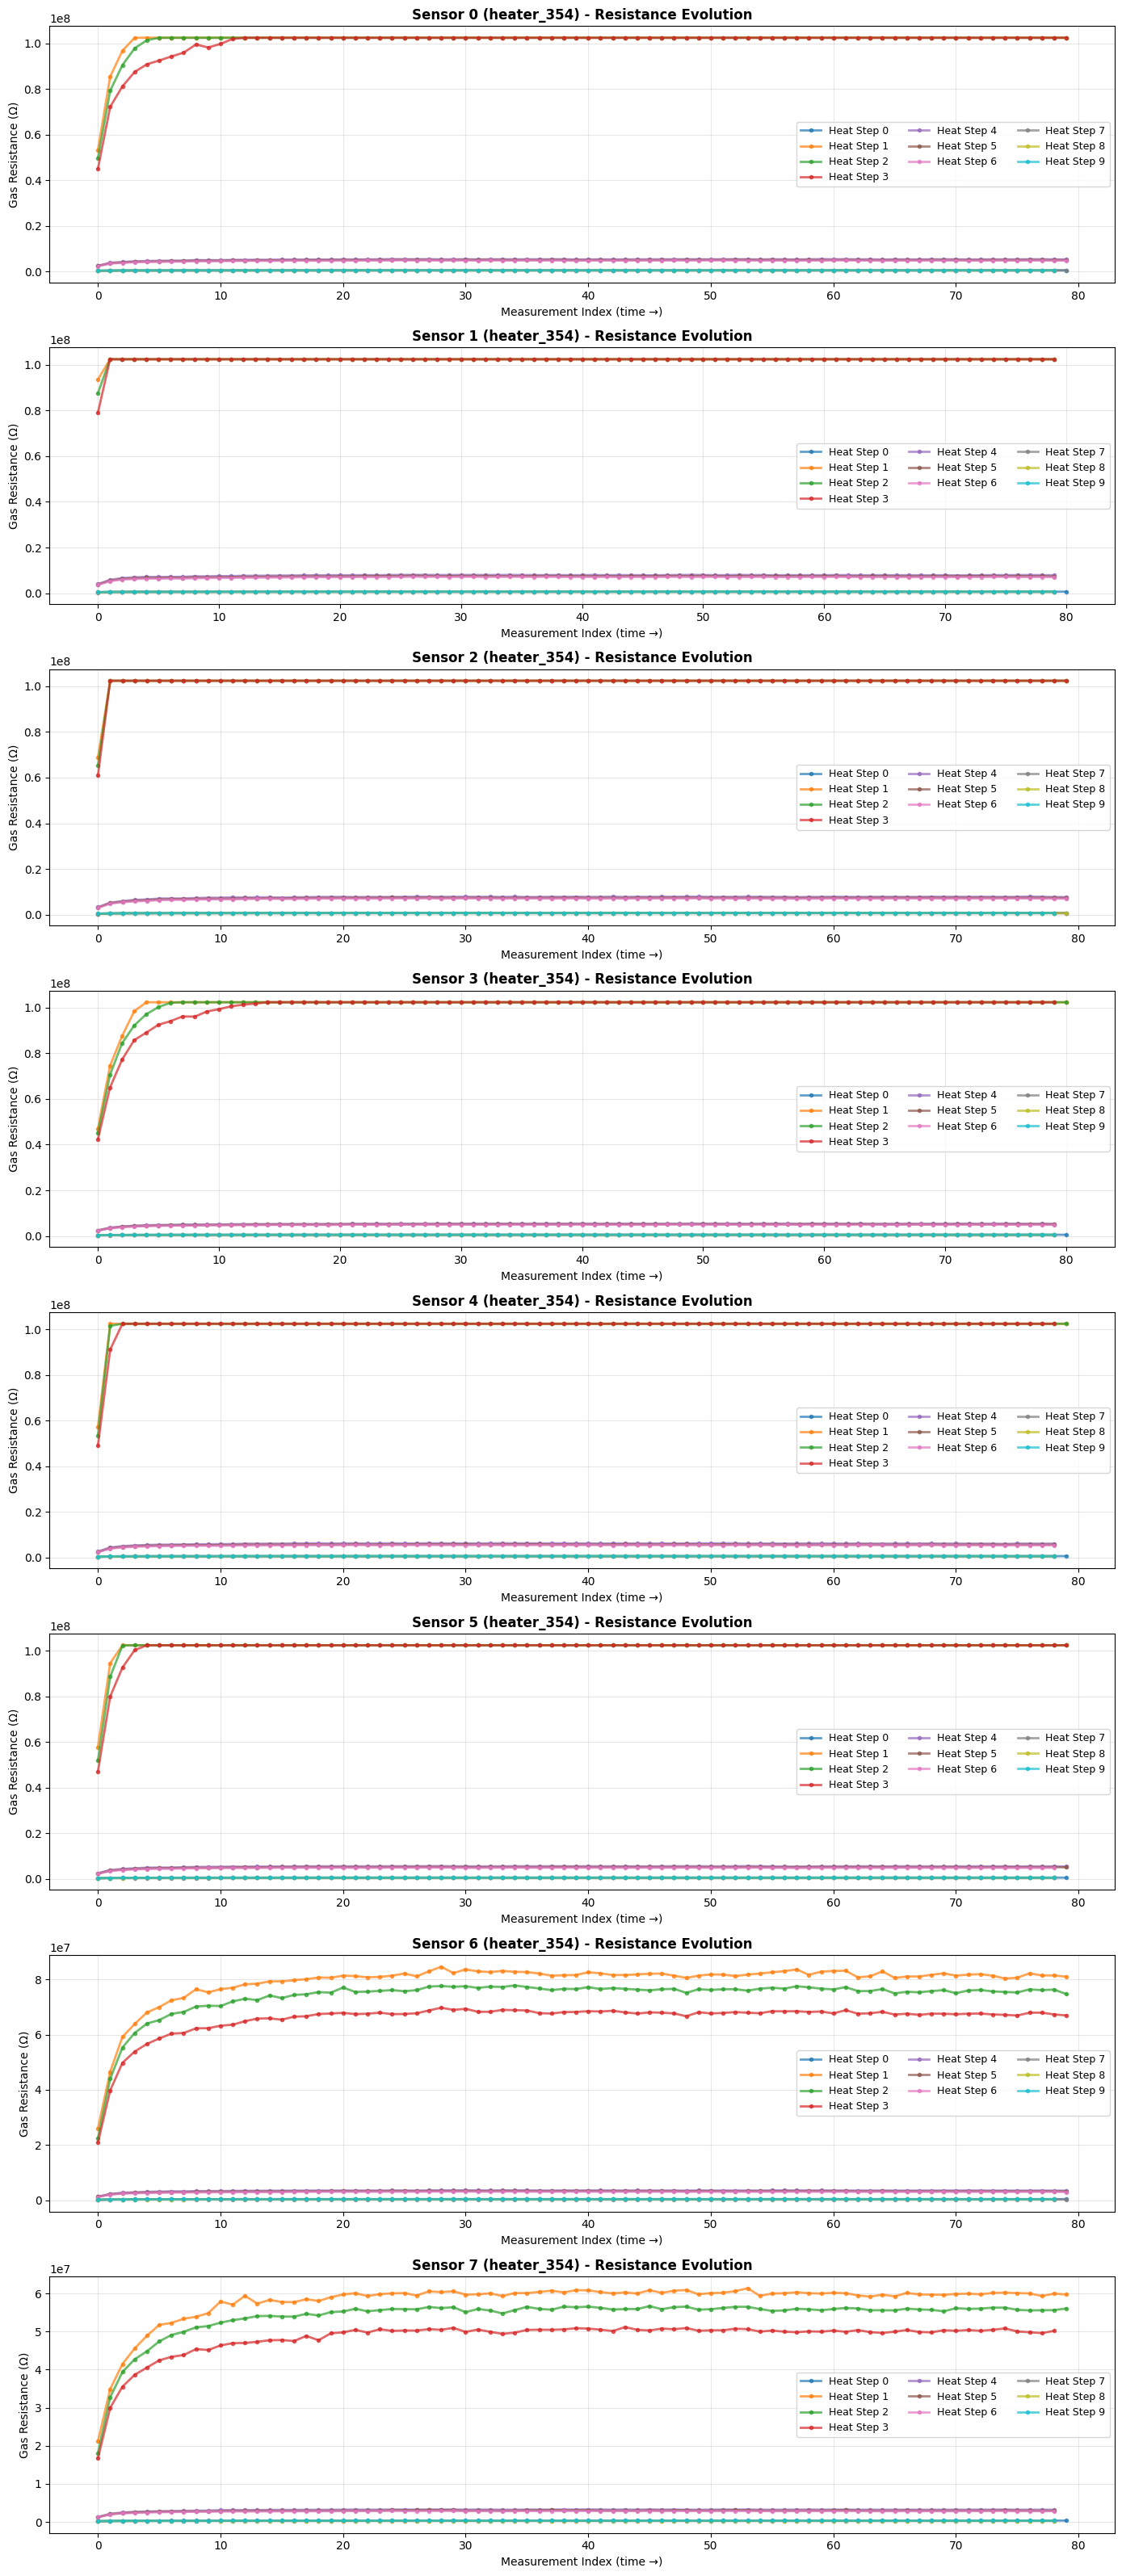

✓ Plot 1 complete: Each line shows one heat step's resistance over time
  - Flat lines = stable measurement
  - Different line heights = different temperatures give different responses


In [24]:
# PLOT 1: Resistance evolution for each sensor or see resistance changes over time
num_sensors = len(resistance_data)
fig, axes = plt.subplots(num_sensors, 1, figsize=(14, 4*num_sensors))

if num_sensors == 1:
    axes = [axes]

for ax_idx, (sensor_idx, steps_data) in enumerate(sorted(resistance_data.items())):
    ax = axes[ax_idx]
    profile = sensor_profile_map.get(sensor_idx, "Unknown")
    
    # Plot each heat step as a line
    for heat_step_idx in sorted(steps_data.keys()):
        resistance_values = steps_data[heat_step_idx]
        ax.plot(resistance_values, label=f"Heat Step {heat_step_idx}", 
               alpha=0.7, linewidth=2, marker='.')
    
    ax.set_title(f"Sensor {sensor_idx} ({profile}) - Resistance Evolution", 
                fontsize=12, fontweight='bold')
    ax.set_xlabel("Measurement Index (time →)")
    ax.set_ylabel("Gas Resistance (Ω)")
    ax.legend(loc='best', ncol=3, fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Plot 1 complete: Each line shows one heat step's resistance over time")
print("  - Flat lines = stable measurement")
print("  - Different line heights = different temperatures give different responses")

C:\Users\yonat\AppData\Local\Temp\ipykernel_14640\2026841189.py:47: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


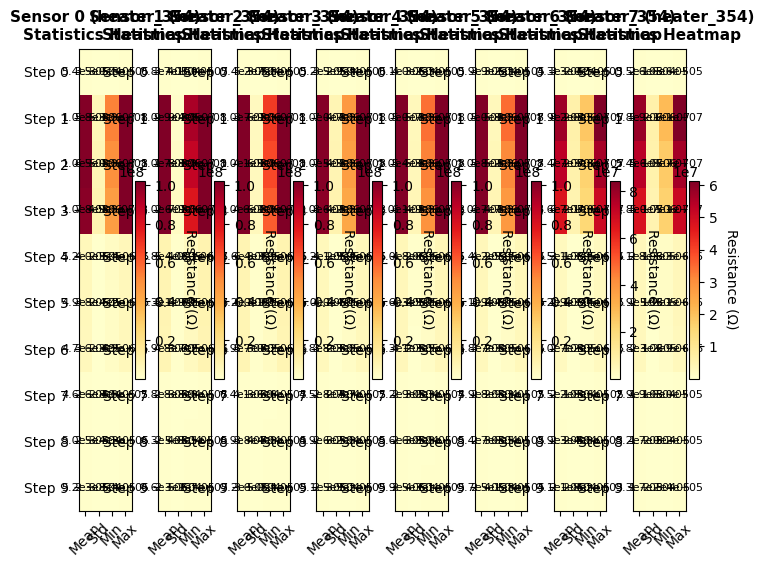

✓ Plot 2 complete: Heatmap shows statistics for each heat step
  - Darker colors = higher resistance
  - Compare Mean across steps to see gas response at different temperatures


In [29]:
# PLOT 2: Heatmap of statistics per heat step
num_sensors = len(resistance_data)
fig, axes = plt.subplots(1, num_sensors, figsize=(8, 6))

if num_sensors == 1:
    axes = [axes]

for ax_idx, (sensor_idx, steps_data) in enumerate(sorted(resistance_data.items())):
    heat_steps = sorted(steps_data.keys())
    
    # Calculate statistics
    stats = []
    for heat_step in heat_steps:
        values = steps_data[heat_step]
        stats.append([
            np.mean(values),
            np.std(values),
            np.min(values),
            np.max(values)
        ])
    
    stats = np.array(stats)
    
    # Create heatmap
    ax = axes[ax_idx]
    im = ax.imshow(stats, aspect='auto', cmap='YlOrRd', interpolation='nearest')
    
    ax.set_yticks(range(len(heat_steps)))
    ax.set_yticklabels([f"Step {h}" for h in heat_steps])
    ax.set_xticks(range(4))
    ax.set_xticklabels(['Mean', 'Std', 'Min', 'Max'], rotation=45)
    
    profile = sensor_profile_map.get(sensor_idx, "Unknown")
    ax.set_title(f"Sensor {sensor_idx} ({profile})\nStatistics Heatmap", 
                fontweight='bold', fontsize=11)
    
    # Add text
    for i in range(len(heat_steps)):
        for j in range(4):
            value = stats[i, j]
            text = ax.text(j, i, f'{value:.1e}',
                         ha="center", va="center", color="black", fontsize=8)
    
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Resistance (Ω)', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

print("✓ Plot 2 complete: Heatmap shows statistics for each heat step")
print("  - Darker colors = higher resistance")
print("  - Compare Mean across steps to see gas response at different temperatures")

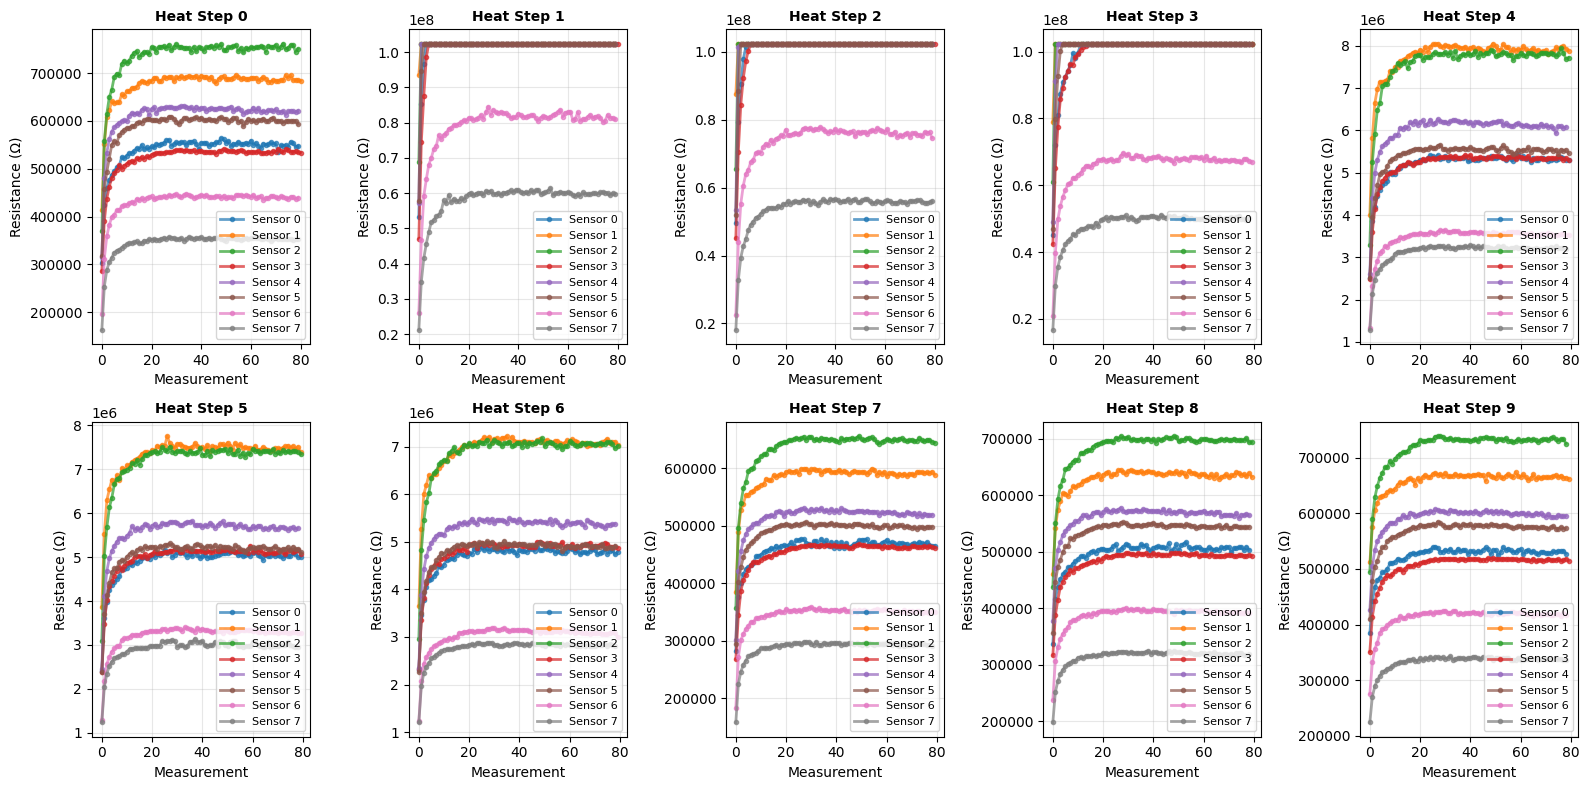

✓ Plot 3 complete: Each subplot shows one heat step
  - Multiple lines = multiple sensors at same temperature
  - Lines close together = sensors well-matched
  - Lines far apart = sensor drift or variation


In [30]:
# PLOT 3: Compare all sensors at each heat step
all_heat_steps = set()
for steps_data in resistance_data.values():
    all_heat_steps.update(steps_data.keys())

num_steps = len(all_heat_steps)
fig, axes = plt.subplots(2, 5, figsize=(16, 8))
axes = axes.flatten()

for step_idx, heat_step in enumerate(sorted(all_heat_steps)):
    ax = axes[step_idx]
    
    for sensor_idx in sorted(resistance_data.keys()):
        if heat_step in resistance_data[sensor_idx]:
            profile = sensor_profile_map.get(sensor_idx, "Unknown")
            values = resistance_data[sensor_idx][heat_step]
            ax.plot(values, label=f"Sensor {sensor_idx}", 
                   alpha=0.7, linewidth=2, marker='o', markersize=3)
    
    ax.set_title(f"Heat Step {heat_step}", fontweight='bold', fontsize=10)
    ax.set_xlabel("Measurement")
    ax.set_ylabel("Resistance (Ω)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Hide unused plots
for step_idx in range(num_steps, len(axes)):
    axes[step_idx].set_visible(False)

plt.tight_layout()
plt.show()

print("✓ Plot 3 complete: Each subplot shows one heat step")
print("  - Multiple lines = multiple sensors at same temperature")
print("  - Lines close together = sensors well-matched")
print("  - Lines far apart = sensor drift or variation")

C:\Users\yonat\AppData\Local\Temp\ipykernel_14640\173428584.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_box, labels=labels, patch_artist=True)
C:\Users\yonat\AppData\Local\Temp\ipykernel_14640\173428584.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_box, labels=labels, patch_artist=True)
C:\Users\yonat\AppData\Local\Temp\ipykernel_14640\173428584.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_box, labels=labels, patch_artist=True)
C:\Users\yonat\AppData\Local\Temp\ipykernel_14640\173428584.py:19: MatplotlibDeprecationWarnin

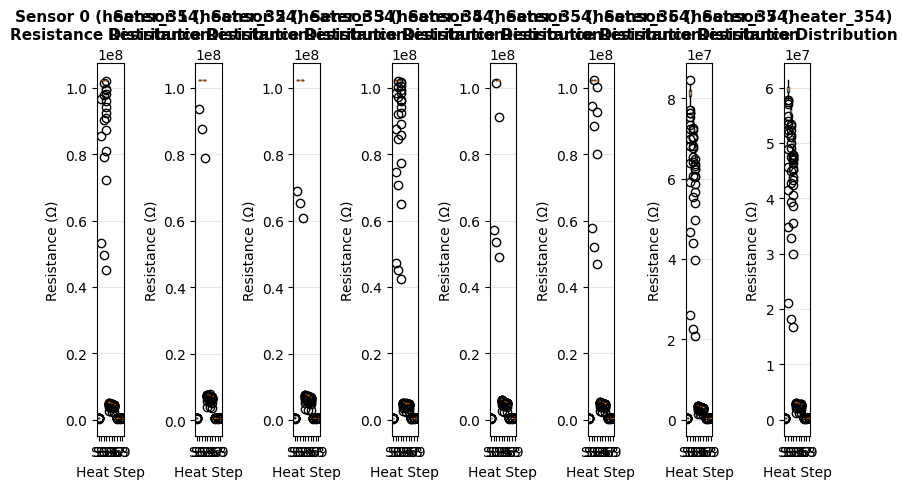

✓ Plot 4 complete: Box plot shows data distribution
  - Box = middle 50% of data
  - Line in box = median
  - Narrow box = stable measurement
  - Wide box = noisy measurement


In [31]:
# PLOT 4: Box plot showing resistance distribution
num_sensors = len(resistance_data)
fig, axes = plt.subplots(1, num_sensors, figsize=(8, 5))

if num_sensors == 1:
    axes = [axes]

for ax_idx, (sensor_idx, steps_data) in enumerate(sorted(resistance_data.items())):
    ax = axes[ax_idx]
    
    # Prepare data
    data_for_box = []
    labels = []
    for heat_step in sorted(steps_data.keys()):
        data_for_box.append(steps_data[heat_step])
        labels.append(f"S{heat_step}")
    
    # Create box plot
    bp = ax.boxplot(data_for_box, labels=labels, patch_artist=True)
    
    # Color boxes
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
        patch.set_alpha(0.7)
    
    profile = sensor_profile_map.get(sensor_idx, "Unknown")
    ax.set_title(f"Sensor {sensor_idx} ({profile})\nResistance Distribution", 
                fontweight='bold', fontsize=11)
    ax.set_ylabel("Resistance (Ω)")
    ax.set_xlabel("Heat Step")
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✓ Plot 4 complete: Box plot shows data distribution")
print("  - Box = middle 50% of data")
print("  - Line in box = median")
print("  - Narrow box = stable measurement")
print("  - Wide box = noisy measurement")

In [32]:
#detailed statistics or summary analysisprint("=" * 80)
print("ANALYSIS SUMMARY")
print("=" * 80)

for sensor_idx in sorted(resistance_data.keys()):
    print(f"\nSensor {sensor_idx}:")
    profile = sensor_profile_map.get(sensor_idx)
    print(f"  Profile: {profile}")
    
    all_values = []
    for heat_step in resistance_data[sensor_idx].values():
        all_values.extend(heat_step)
    
    print(f"  Total measurements: {len(all_values)}")
    print(f"  Resistance range: {min(all_values):.0f} - {max(all_values):.0f} Ω")
    print(f"  Average: {np.mean(all_values):.0f} Ω")
    print(f"  Std Dev: {np.std(all_values):.0f} Ω")
    
    # Per heat step
    print(f"  By heat step:")
    for heat_step in sorted(resistance_data[sensor_idx].keys()):
        values = resistance_data[sensor_idx][heat_step]
        print(f"    Step {heat_step}: {np.mean(values):.0f} ± {np.std(values):.0f} Ω " +
              f"({min(values):.0f} - {max(values):.0f})")

ANALYSIS SUMMARY

Sensor 0:
  Profile: heater_354
  Total measurements: 798
  Resistance range: 283186 - 102400000 Ω
  Average: 32062536 Ω
  Std Dev: 45401390 Ω
  By heat step:
    Step 0: 540325 ± 35086 Ω (303858 - 564032)
    Step 1: 101501988 ± 5781315 Ω (53238016 - 102400000)
    Step 2: 101230812 ± 6492593 Ω (49695544 - 102400000)
    Step 3: 100268465 ± 7829200 Ω (44980096 - 102400000)
    Step 4: 5198958 ± 402400 Ω (2513654 - 5432360)
    Step 5: 4924919 ± 379770 Ω (2409412 - 5170085)
    Step 6: 4688316 ± 358317 Ω (2309557 - 4896593)
    Step 7: 460713 ± 26099 Ω (283186 - 477278)
    Step 8: 498367 ± 24943 Ω (336510 - 517041)
    Step 9: 523714 ± 22659 Ω (383880 - 539942)

Sensor 1:
  Profile: heater_354
  Total measurements: 801
  Resistance range: 384529 - 102400000 Ω
  Average: 33078224 Ω
  Std Dev: 45310707 Ω
  By heat step:
    Step 0: 677014 ± 36926 Ω (413403 - 696362)
    Step 1: 102289033 ± 986294 Ω (93522656 - 102400000)
    Step 2: 102214090 ± 1652402 Ω (87527216 - 10